In [1]:
import numpy as np
import matplotlib as mpl
import glob
import os
import matplotlib.pyplot as plt
import numpy.ma as ma
from scipy import stats
import xarray as xr
import commondefs as myF
from mpl_toolkits.basemap import Basemap

plt.rcParams.update({'font.size': 10})

In [2]:
mydir = '../processed_netcdf/'

In [3]:
def is_feb(month):
    return month==2

def is_sep(month):
    return month==9

In [4]:
moddir = '../processed_netcdf/CMIP6_sic_1979-2014_clim/'
allfiles = sorted([f for f in os.listdir(moddir) if 'siconc_SImon' in f])
modnames = [f.split('_')[2] for f in allfiles]

obsdir='../processed_netcdf/OBS_sic_1979-2014_clim/'
obsnames = ['Bootstrap','NASA-Team','osisaf']
modnames = sorted(list(set(modnames)))
nobs = len(obsnames)
names = obsnames+ modnames
print(names)
nmod = len(names)
print(len(names))

['Bootstrap', 'NASA-Team', 'osisaf', 'ACCESS-CM2', 'ACCESS-ESM1-5', 'AWI-CM-1-1-MR', 'BCC-CSM2-MR', 'BCC-ESM1', 'CAMS-CSM1-0', 'CESM2', 'CESM2-WACCM', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'CanESM5', 'E3SM-1-0', 'EC-Earth3', 'EC-Earth3-Veg', 'FGOALS-f3-L', 'FGOALS-g3', 'GFDL-CM4', 'GFDL-ESM4', 'GISS-E2-1-H', 'HadGEM3-GC31-LL', 'HadGEM3-GC31-MM', 'INM-CM4-8', 'INM-CM5-0', 'IPSL-CM6A-LR', 'MIROC-ES2L', 'MIROC6', 'MPI-ESM1-2-HR', 'MPI-ESM1-2-LR', 'MRI-ESM2-0', 'NESM3', 'NorCPM1', 'NorESM2-LM', 'SAM0-UNICON', 'UKESM1-0-LL']
38


In [5]:
maps = [Basemap(projection='npstere', boundinglat=55, lon_0 = 0),Basemap(projection='spstere', boundinglat=-55, lon_0 = 180)]

/Users/lettieroach/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:1: MatplotlibDeprecationWarning: 
The dedent function was deprecated in Matplotlib 3.1 and will be removed in 3.3. Use inspect.cleandoc instead.
  """Entry point for launching an IPython kernel.


In [6]:
listds = []
lats = []
lons = []

for n,name in enumerate(names):
    
    if n<nobs:
        mydir = obsdir
    else:
        mydir = moddir
    ensfiles = [f for f in os.listdir(mydir) if name+'_' in f][0]
    ds = xr.open_dataset(mydir+ensfiles)
    if 'siconc' not in ds:
        if 'sic' in ds:
            ds = ds.rename({'sic':'siconc'})
        elif 'seaice' in ds:
            ds = ds.rename({'seaice':'siconc'})
        ds.siconc.values = 100.*ds.siconc.values
    #print(np.nanmax(ds.siconc.values))
    
    listds.append(ds)
    lat,lon = myF.get_lats(ds)
    lats.append(lat)
    lons.append(lon)

Bootstrap


/Users/lettieroach/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:16: RuntimeWarning: invalid value encountered in less
  app.launch_new_instance()


NASA-Team
OSISAF
ACCESS-CM2
ACCESS-ESM1-5
AWI-CM-1-1-MR
BCC-CSM2-MR
BCC-ESM1
CAMS-CSM1-0
CESM2
CESM2-WACCM
CNRM-CM6-1
CNRM-CM6-1-HR
CNRM-ESM2-1
CanESM5
E3SM-1-0
EC-Earth3
EC-Earth3-Veg
FGOALS-f3-L
FGOALS-g3
GFDL-CM4
GFDL-ESM4
GISS-E2-1-H
HadGEM3-GC31-LL
HadGEM3-GC31-MM
INM-CM4-8
INM-CM5-0
IPSL-CM6A-LR
MIROC-ES2L
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NESM3
NorCPM1
NorESM2-LM
SAM0-UNICON
UKESM1-0-LL


/Users/lettieroach/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


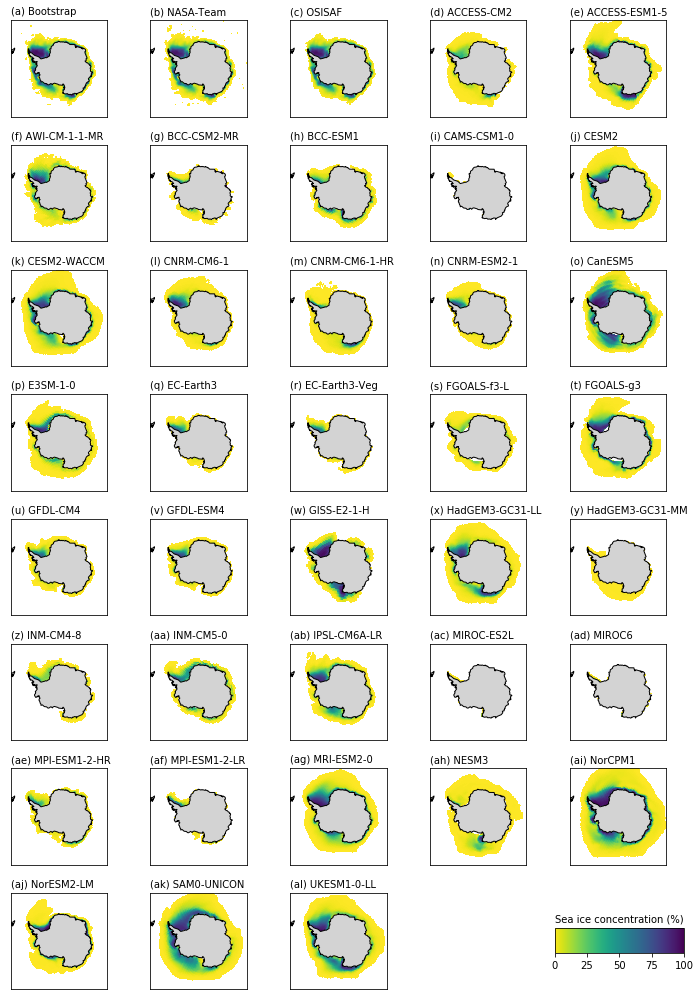

Bootstrap
NASA-Team
OSISAF
ACCESS-CM2
ACCESS-ESM1-5
AWI-CM-1-1-MR
BCC-CSM2-MR
BCC-ESM1
CAMS-CSM1-0
CESM2
CESM2-WACCM
CNRM-CM6-1
CNRM-CM6-1-HR
CNRM-ESM2-1
CanESM5
E3SM-1-0
EC-Earth3
EC-Earth3-Veg
FGOALS-f3-L
FGOALS-g3
GFDL-CM4
GFDL-ESM4
GISS-E2-1-H
HadGEM3-GC31-LL
HadGEM3-GC31-MM
INM-CM4-8
INM-CM5-0
IPSL-CM6A-LR
MIROC-ES2L
MIROC6
MPI-ESM1-2-HR
MPI-ESM1-2-LR
MRI-ESM2-0
NESM3
NorCPM1
NorESM2-LM
SAM0-UNICON
UKESM1-0-LL


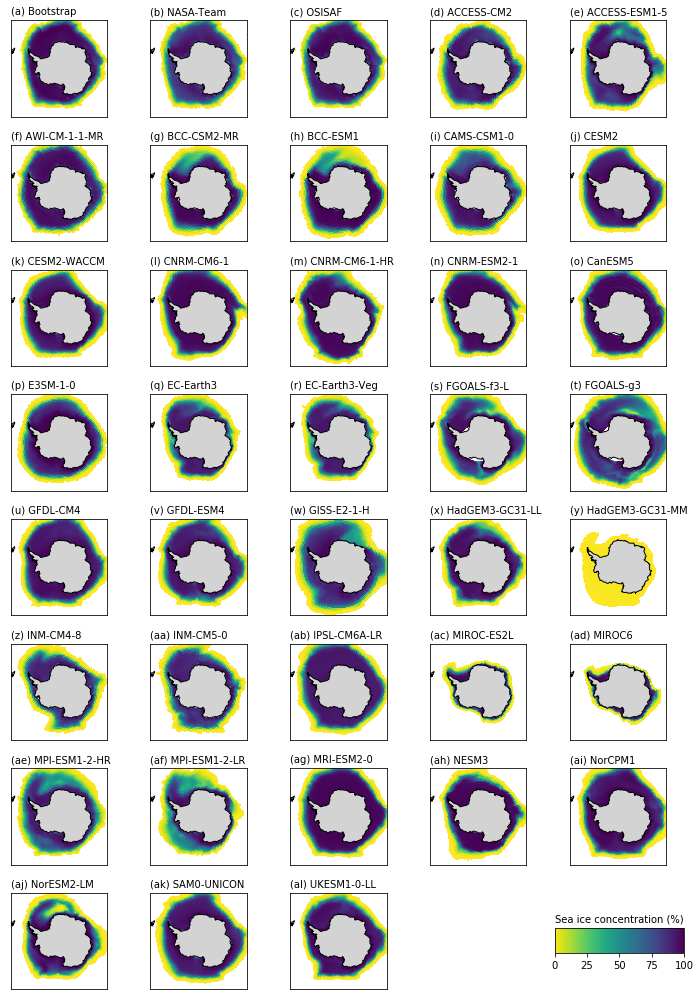

CPU times: user 1min 51s, sys: 5.68 s, total: 1min 56s
Wall time: 1min 27s


In [8]:
%%time
names[2] = 'OSISAF'
h = 1
for month in [1,8]:
    fig = plt.figure(figsize=(10,14))
    for mod in range(nmod):
        print(names[mod])
        mydata = listds[mod].siconc[month,:,:]
        
        ax = plt.subplot(8,5,mod+1)
        ax.set_title(myF.alphabet[mod]+' '+names[mod],fontsize=10,loc='left')
        m = maps[h]
        x, y = m(lons[mod],lats[mod])
        
        mydata = ma.masked_where(lats[mod]>0,mydata)
        mydata = ma.masked_invalid(mydata)
        mydata = ma.masked_where(mydata<0.1,mydata)
        CS1 = m.pcolor(x,y,mydata,cmap = plt.cm.viridis_r,vmin=0.,vmax=100.)       
        m.drawcoastlines(color='black')
        m.fillcontinents(color='lightgrey')

    cbar_ax = fig.add_axes([0.78, 0.05, 0.18, 0.025]) #[left, bottom, width, height]
    cbar = fig.colorbar(CS1, cax=cbar_ax,  orientation='horizontal')
    cbar.ax.set_title(r'Sea ice concentration (%)',fontsize=10)
    plt.tight_layout()
    
    #fig.savefig(savedir+'cmip6_mean_sic_sh_'+str(month)+'_1979-2018',bbox_inches='tight',dpi=600)
    plt.show()
    plt.close()